In [18]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import random

#############################################################################################
# TODO: MOVE THIS ALL TO INDEPENDENT .PY FILE, JUPYTER NOTEBOOK ONLY FOR EASY VISUALIZATION #
#############################################################################################

class KITTIDepthInpaintingDataset(Dataset):
    """
    KITTI Depth Inpainting Dataset 

    For each depth map D:
      - D is from data_depth_annotated (semi-dense KITTI fused depth)
      - Convert 16-bit PNG to float32 depth in meters
      - Make a corrupted copy by blanking out random rectangular regions
      - Return (corrupted_depth, original_depth, valid_mask)

    Returned tensors:
      input_depth:  [1,H,W] float32, meters, 0 where either originally invalid OR masked out
      target_depth: [1,H,W] float32, meters, original semi-dense depth
      valid_mask:   [1,H,W] bool, True where KITTI has actual ground truth depth
    """

    def __init__(
        self,
        annotated_root,
        split='train',
        resize_to=(256, 1216),   # (H,W) or None to keep native
        n_rectangles=(1, 3),     # random number of holes per sample
        hole_frac_range=(0.05, 0.20),  # each hole covers 5%-20% of the image area hole_frac_range=(0.01, 0.05) (0.05, 0.20)

        normalize=False,
        max_depth_m=80.0,
        seed=None
    ):
        """
        annotated_root: path to 'data_depth_annotated'
        split: 'train' or 'val'
        resize_to: (H,W) final spatial size for network input/output. If None, keep original KITTI size.
        n_rectangles: tuple(int,int), inclusive range for number of synthetic occlusion rectangles
        hole_frac_range: tuple(float,float), area fraction of each rectangle w.r.t. full image
        normalize: if True, we divide depth maps by max_depth_m so values lie in [0,1] approximately
        max_depth_m: depth cap for normalization
        seed: optional random seed for reproducibility (mask locations etc.)
        """
        self.annotated_root = Path(annotated_root) / split
        self.resize_to = resize_to
        self.n_rectangles = n_rectangles
        self.hole_frac_range = hole_frac_range
        self.normalize = normalize
        self.max_depth_m = max_depth_m

        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

        # Collect all .png files in this split
        self.depth_paths = sorted(self.annotated_root.rglob('*.png'))
        if len(self.depth_paths) == 0:
            raise RuntimeError(
                f"No depth maps found under {self.annotated_root}. "
                "Check that annotated_root points to data_depth_annotated/"
            )

    def __len__(self):
        return len(self.depth_paths)

    def _load_depth_meters(self, p):
        """
        KITTI depth completion annotated images are 16-bit PNGs.
        Pixel value 0   => invalid / no measurement.
        Pixel value v>0 => depth (in meters) == v / 256.0

        We load as uint16, convert to float32 meters, optionally resize.
        """
        depth16 = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)  # HxW, uint16
        if depth16 is None:
            raise RuntimeError(f"Failed to read depth map {p}")

        # optional resize (NEAREST so we don't interpolate depth values weirdly)
        if self.resize_to is not None:
            H, W = self.resize_to
            depth16 = cv2.resize(
                depth16,
                (W, H),
                interpolation=cv2.INTER_NEAREST
            )

        depth_m = depth16.astype(np.float32) / 256.0  # meters
        return depth_m  # shape (H,W), float32

    def _apply_random_holes(self, depth, valid_mask):
        """
        depth:      (H,W) float32, meters
        valid_mask: (H,W) bool, True where depth>0

        We create a corrupted copy by zeroing out rectangular regions, simulating occlusions.
        Importantly: we are zeroing the depth values. That looks like "missing data."
        """
        H, W = depth.shape
        corrupted = depth.copy()

        # we don't actually change valid_mask for training,
        # because we WANT supervision inside the holes.
        # valid_mask still represents "ground truth exists here in the original data".
        num_rects = random.randint(self.n_rectangles[0], self.n_rectangles[1])
        img_area = H * W

        for _ in range(num_rects):
            # pick area fraction for this hole
            frac = random.uniform(self.hole_frac_range[0], self.hole_frac_range[1])
            target_area = frac * img_area

            # random aspect ratio between about square and elongated
            aspect = random.uniform(0.5, 2.0)
            hole_h = int(np.sqrt(target_area / aspect))
            hole_w = int(aspect * hole_h)

            hole_h = max(1, min(H, hole_h))
            hole_w = max(1, min(W, hole_w))

            y0 = random.randint(0, H - hole_h)
            x0 = random.randint(0, W - hole_w)

            # wipe that region
            corrupted[y0:y0+hole_h, x0:x0+hole_w] = 0.0

        return corrupted

    def __getitem__(self, idx):
        depth_m = self._load_depth_meters(self.depth_paths[idx])  # (H,W) float32

        # valid pixels are where KITTI has any measurement at all
        valid_mask = depth_m > 0.0  # (H,W) bool

        # create corrupted version with synthetic occlusions
        corrupted_m = self._apply_random_holes(depth_m, valid_mask)

        # optional normalization to ~[0,1] (helps training stability sometimes)
        if self.normalize:
            target_depth = np.clip(depth_m / self.max_depth_m, 0.0, 1.0)
            input_depth  = np.clip(corrupted_m / self.max_depth_m, 0.0, 1.0)
        else:
            target_depth = depth_m
            input_depth  = corrupted_m

        # (C,H,W) tensors for PyTorch
        input_depth  = torch.from_numpy(input_depth).unsqueeze(0).float()   # [1,H,W]
        target_depth = torch.from_numpy(target_depth).unsqueeze(0).float()  # [1,H,W]
        valid_mask_t = torch.from_numpy(valid_mask).unsqueeze(0).bool()     # [1,H,W]

        return {
            "input_depth":  input_depth,      # corrupted, holes zeroed
            "target_depth": target_depth,     # original semi-dense depth
            "valid_mask":   valid_mask_t,     # True where ground truth exists
            "path":         str(self.depth_paths[idx])
        }


def get_inpainting_loader(
    annotated_root,
    split='train',
    batch_size=4,
    shuffle=True,
    num_workers=0,
    resize_to=(256,1216),
    normalize=False,
    seed=None
):
    """
    Convenience wrapper to create a DataLoader.
    """
    ds = KITTIDepthInpaintingDataset(
        annotated_root=annotated_root,
        split=split,
        resize_to=resize_to,
        normalize=normalize,
        seed=seed
    )

    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=(split == 'train' and shuffle),
        num_workers=num_workers,
        pin_memory=True
    )

    return dl


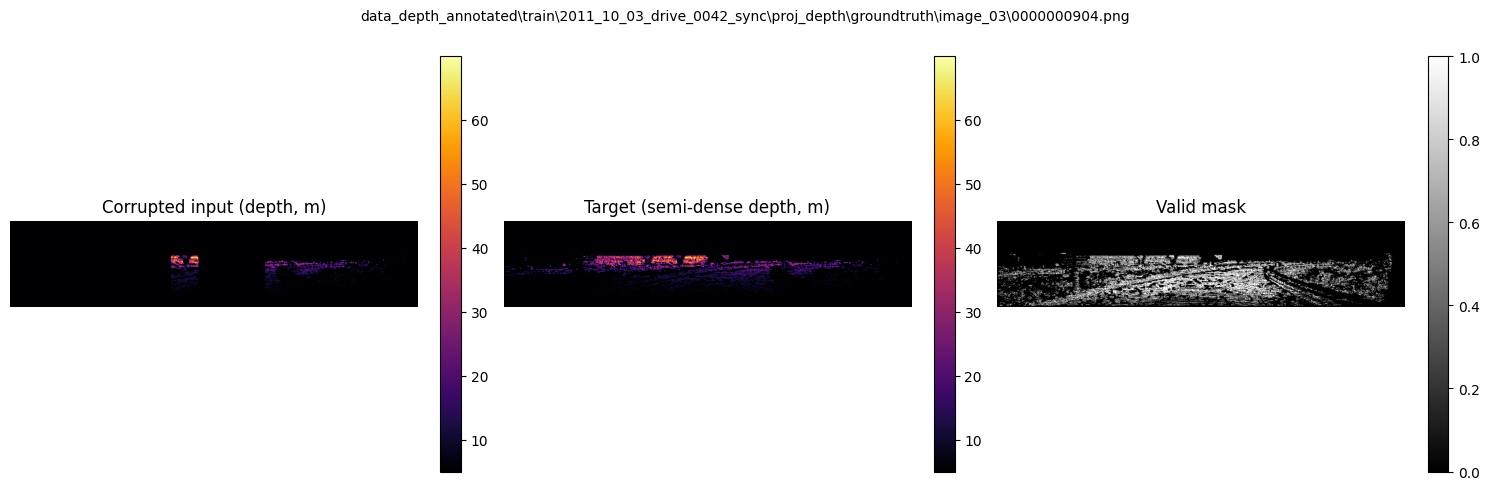

In [19]:
import matplotlib as plt
import numpy as np
from torch.utils.data import Dataset

# class KITTIDepthInpaintingDatasetDebug(Dataset):
#     """
#     Thin wrapper: takes an existing full dataset and only exposes the first N items.
#     This avoids scanning / iterating over the whole massive set while just testing.
#     """
#     def __init__(self, base_dataset, max_items=50):
#         self.base = base_dataset
#         self.max_items = min(max_items, len(base_dataset))

#     def __len__(self):
#         return self.max_items

#     def __getitem__(self, idx):
#         return self.base[idx]

# # 1) Build the full dataset ONCE
# full_train_ds = KITTIDepthInpaintingDataset(
#     annotated_root='data_depth_annotated',
#     split='train',
#     resize_to=(256,1216),
#     normalize=False,
#     seed=0
# )

# # 2) Wrap it with the debug subset
# debug_train_ds = KITTIDepthInpaintingDatasetDebug(full_train_ds, max_items=50)

# # 3) Make a super simple DataLoader (no workers, no pin_memory)
# debug_loader = DataLoader(
#     debug_train_ds,
#     batch_size=1,
#     shuffle=False,
#     num_workers=0,
#     pin_memory=False
# )

# Usage example

train_loader = get_inpainting_loader(
    annotated_root='data_depth_annotated',
    split='train',
    batch_size=2,
    resize_to=(256,1216), # could otherwise be (256,1216)
    normalize=False
)

val_loader = get_inpainting_loader(
    annotated_root='data_depth_annotated',
    split='val',
    batch_size=2,
    resize_to=(256,1216),# could otherwise be (256,1216)
    shuffle=False,
    normalize=False
)

# Visualize some here

import matplotlib.pyplot as plt
import numpy as np
import torch

batch = next(iter(train_loader))

inp = batch["input_depth"][0,0].numpy()
tgt = batch["target_depth"][0,0].numpy()
mask = batch["valid_mask"][0,0].numpy()
path = batch["path"][0]

# We'll only consider valid pixels for scaling
valid_tgt_vals = tgt[mask]

# Safety in case something is weird
if valid_tgt_vals.size == 0:
    print("No valid depth pixels in this sample? That's unusual.")
    vmin, vmax = 0.0, 80.0
else:
    vmin = np.percentile(valid_tgt_vals, 1)   # robust lower bound
    vmax = np.percentile(valid_tgt_vals, 99)  # robust upper bound

# For display, let's zero-out invalid pixels instead of NaN
inp_disp = np.zeros_like(inp)
tgt_disp = np.zeros_like(tgt)
inp_disp[mask] = inp[mask]
tgt_disp[mask] = tgt[mask]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f"{path}", fontsize=10)

#TODO: MIGHT WANT TO MAKE CLOSER POINTS BRIGHTER (THE LOWER VALUE OF M)
im0 = axs[0].imshow(inp_disp, cmap='inferno', vmin=vmin, vmax=vmax)
axs[0].set_title("Corrupted input (depth, m)")
plt.colorbar(im0, ax=axs[0], fraction=0.046)

im1 = axs[1].imshow(tgt_disp, cmap='inferno', vmin=vmin, vmax=vmax)
axs[1].set_title("Target (semi-dense depth, m)")
plt.colorbar(im1, ax=axs[1], fraction=0.046)

#TODO: Replace valid mask with valid mask + holes visible by shading the removed points in red 
im2 = axs[2].imshow(mask.astype(np.float32), cmap='gray', vmin=0, vmax=1)
axs[2].set_title("Valid mask")
plt.colorbar(im2, ax=axs[2], fraction=0.046)

for ax in axs:
    ax.axis('off')

plt.tight_layout()
plt.show()



# # # example train loop
# # for batch in train_loader:
# #     x = batch["input_depth"].cuda()      # [B,1,H,W]
# #     y = batch["target_depth"].cuda()     # [B,1,H,W]
# #     m = batch["valid_mask"].cuda()       # [B,1,H,W] bool

# #     # forward pass
# #     # pred = model(x)

# #     # masked L1 loss
# #     # loss = torch.abs(pred - y)[m].mean()

# #     break


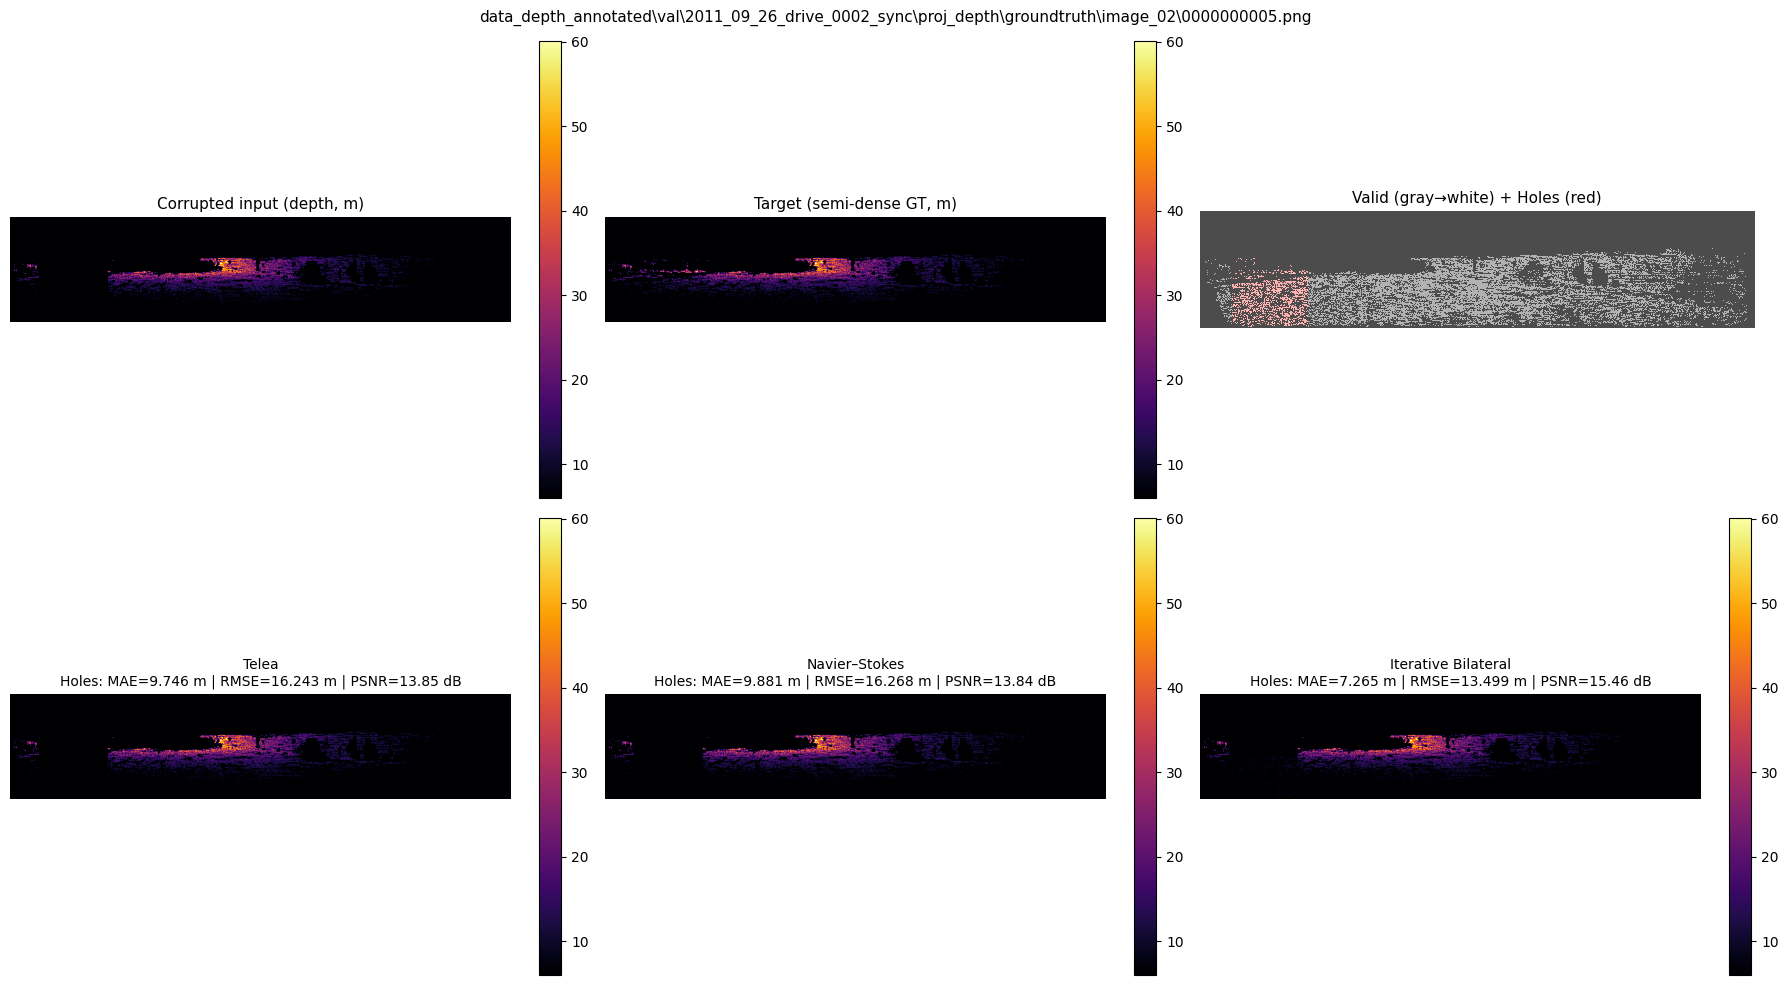

In [27]:
# Image inpainting with classical baselines (TELEA, Navier-Stokes)

# ============================
# Classical baselines + PSNR + 2x3 visualization
# ============================

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

# ---------- helpers: scaling, masks, metrics ----------

def compute_scaling(valid_vals):
    """
    Robust per-image scaling range for display or uint8 proxy (OpenCV inpaint).
    Uses 1st-99th percentiles of valid depth (m). Falls back to [0,80].
    """
    if valid_vals.size == 0:
        return 0.0, 80.0
    vmin = float(np.percentile(valid_vals, 1))
    vmax = float(np.percentile(valid_vals, 99))
    if vmax <= vmin:
        vmax = vmin + 1.0
    return vmin, vmax

def depth_to_uchar(depth_m, vmin, vmax):
    """Map meters -> uint8 [0,255] for OpenCV inpaint (clip then scale)."""
    d = np.clip(depth_m, vmin, vmax)
    d = (255.0 * (d - vmin) / (vmax - vmin)).astype(np.uint8)
    return d

def uchar_to_depth(d8, vmin, vmax):
    """Map uint8 [0,255] back to meters using the same vmin/vmax."""
    d8 = d8.astype(np.float32) / 255.0
    return d8 * (vmax - vmin) + vmin

def make_hole_mask(input_depth_m, target_depth_m):
    """
    Holes are where we zeroed a pixel that actually has GT:
      input == 0 (synthetic occlusion) AND target > 0 (KITTI had a measurement)
    """
    return (input_depth_m == 0.0) & (target_depth_m > 0.0)

def mae_rmse_psnr(pred, gt, region_mask, max_val=80.0):
    """
    Compute MAE, RMSE, and PSNR (in dB) over the given boolean region_mask.
    PSNR = 20*log10(max_val / RMSE). For depth, we default to max_val=80m (KITTI cap).
    """
    m = region_mask
    if m.sum() == 0:
        return np.nan, np.nan, np.nan
    err = (pred[m] - gt[m]).astype(np.float32)
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    if rmse == 0 or np.isnan(rmse):
        psnr = np.inf
    else:
        psnr = float(20.0 * np.log10(max_val / rmse))
    return mae, rmse, psnr

# ---------- Baseline 1: Telea (Fast Marching) ----------

def inpaint_telea_depth(input_depth_m, target_depth_m, radius_px=3):
    """
    OpenCV Telea inpainting on an 8-bit proxy of depth.
    Only holes (input==0 & target>0) are inpainted; known pixels are kept exact.
    """
    depth = input_depth_m.copy()
    hole_mask = make_hole_mask(input_depth_m, target_depth_m).astype(np.uint8)

    valid_vals = target_depth_m[target_depth_m > 0]
    vmin, vmax = compute_scaling(valid_vals)
    d8 = depth_to_uchar(depth, vmin, vmax)
    mask8 = (hole_mask * 255).astype(np.uint8)

    filled8 = cv2.inpaint(d8, mask8, inpaintRadius=radius_px, flags=cv2.INPAINT_TELEA)
    filled_m = uchar_to_depth(filled8, vmin, vmax)

    # Reinstate known pixels exactly
    known = input_depth_m > 0
    filled_m[known] = input_depth_m[known]
    return filled_m

# ---------- Baseline 2: Navier–Stokes ----------

def inpaint_navier_stokes_depth(input_depth_m, target_depth_m, radius_px=3):
    """
    OpenCV Navier-Stokes (Bertalmio et al.) inpainting on 8-bit proxy.
    Preserves isophotes; slower than Telea.
    """
    depth = input_depth_m.copy()
    hole_mask = make_hole_mask(input_depth_m, target_depth_m).astype(np.uint8)

    valid_vals = target_depth_m[target_depth_m > 0]
    vmin, vmax = compute_scaling(valid_vals)
    d8 = depth_to_uchar(depth, vmin, vmax)
    mask8 = (hole_mask * 255).astype(np.uint8)

    filled8 = cv2.inpaint(d8, mask8, inpaintRadius=radius_px, flags=cv2.INPAINT_NS)
    filled_m = uchar_to_depth(filled8, vmin, vmax)

    known = input_depth_m > 0
    filled_m[known] = input_depth_m[known]
    return filled_m

# ---------- Baseline 3: Iterative edge-aware (bilateral-inpaint) ----------

def bilateral_inpaint_depth(input_depth_m, target_depth_m, iters=8, d=7, sigma_color=3.0, sigma_space=7.0):
    """
    Depth-only iterative fill:
      - Apply bilateral filter to current depth
      - Copy filtered values into holes only
      - Keep known pixels fixed (Dirichlet boundary)
    Repeat 'iters' times.
    """
    depth = input_depth_m.copy()
    hole_mask = make_hole_mask(input_depth_m, target_depth_m)

    if not hole_mask.any():
        return depth

    # Optional seed to avoid flat zero patches creating shocks
    if np.all(depth[hole_mask] == 0):
        known = depth[input_depth_m > 0]
        seed_val = np.median(known) if known.size > 0 else 0.0
        depth[hole_mask] = seed_val

    for _ in range(iters):
        bf = cv2.bilateralFilter(depth.astype(np.float32), d=d, sigmaColor=sigma_color, sigmaSpace=sigma_space)
        depth[hole_mask] = bf[hole_mask]

    known = input_depth_m > 0
    depth[known] = input_depth_m[known]
    return depth

# ---------- 2x3 Visualization with metrics ----------

def visualize_2x3_with_metrics(inp_m, tgt_m, telea_m, ns_m, bilin_m, title="", max_val_for_psnr=80.0):
    """
    2x3 grid:
      Row 1: Corrupted input | Target (GT) | Valid / Holes overlay
      Row 2: Telea (metrics) | Navier–Stokes (metrics) | Bilateral-inpaint (metrics)
    Metrics shown: MAE / RMSE / PSNR (holes-only). Also compute 'all-valid' if you want to print it.
    """
    H, W = tgt_m.shape
    valid_mask = (tgt_m > 0)
    hole_mask  = make_hole_mask(inp_m, tgt_m)

    # Display range from valid GT
    vals = tgt_m[valid_mask]
    vmin, vmax = compute_scaling(vals)

    def disp(d):
        out = np.zeros_like(d)
        out[valid_mask] = d[valid_mask]
        return out

    # Compute metrics (holes-only)
    telea_h = mae_rmse_psnr(telea_m, tgt_m, hole_mask & valid_mask, max_val=max_val_for_psnr)
    ns_h    = mae_rmse_psnr(ns_m, tgt_m, hole_mask & valid_mask, max_val=max_val_for_psnr)
    bilin_h = mae_rmse_psnr(bilin_m, tgt_m, hole_mask & valid_mask, max_val=max_val_for_psnr)

    # Optionally also compute all-valid (not displayed, but handy)
    telea_all = mae_rmse_psnr(telea_m, tgt_m, valid_mask, max_val=max_val_for_psnr)
    ns_all    = mae_rmse_psnr(ns_m, tgt_m, valid_mask, max_val=max_val_for_psnr)
    bilin_all = mae_rmse_psnr(bilin_m, tgt_m, valid_mask, max_val=max_val_for_psnr)

    # Build a nice overlay for holes/valid
    overlay = np.zeros((H, W, 3), dtype=np.float32)
    # valid pixels in gray
    overlay[..., :] = 0.3
    overlay[valid_mask, :] = 0.7
    # holes in red where GT exists but input is zero
    rr, cc = np.where(hole_mask & valid_mask)
    overlay[rr, cc, 0] = 1.0  # red channel

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # bigger figure

    # Row 1
    im0 = axs[0,0].imshow(disp(inp_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[0,0].set_title("Corrupted input (depth, m)", fontsize=11)
    axs[0,0].axis("off")
    plt.colorbar(im0, ax=axs[0,0], fraction=0.046)

    im1 = axs[0,1].imshow(disp(tgt_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[0,1].set_title("Target (semi-dense GT, m)", fontsize=11)
    axs[0,1].axis("off")
    plt.colorbar(im1, ax=axs[0,1], fraction=0.046)

    axs[0,2].imshow(overlay, interpolation="nearest")
    axs[0,2].set_title("Valid (gray→white) + Holes (red)", fontsize=11)
    axs[0,2].axis("off")

    # Row 2: methods + titles with metrics (holes-only)
    def tlabel(name, triplet):
        mae, rmse, psnr = triplet
        return f"{name}\nHoles: MAE={mae:.3f} m | RMSE={rmse:.3f} m | PSNR={psnr:.2f} dB"

    im2 = axs[1,0].imshow(disp(telea_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[1,0].set_title(tlabel("Telea", telea_h), fontsize=10)
    axs[1,0].axis("off")
    plt.colorbar(im2, ax=axs[1,0], fraction=0.046)

    im3 = axs[1,1].imshow(disp(ns_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[1,1].set_title(tlabel("Navier–Stokes", ns_h), fontsize=10)
    axs[1,1].axis("off")
    plt.colorbar(im3, ax=axs[1,1], fraction=0.046)

    im4 = axs[1,2].imshow(disp(bilin_m), cmap="inferno", vmin=vmin, vmax=vmax)
    axs[1,2].set_title(tlabel("Iterative Bilateral", bilin_h), fontsize=10)
    axs[1,2].axis("off")
    plt.colorbar(im4, ax=axs[1,2], fraction=0.046)

    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

# ---------- Convenience: run baselines on one sample and visualize ----------

def run_and_show_one(batch, index=0, telea_radius=3, ns_radius=3,
                     bilin_iters=8, bilin_d=7, bilin_sigma_color=3.0, bilin_sigma_space=7.0,
                     psnr_max_val=80.0):
    """
    batch: dict from your DataLoader
    index: which element in the batch to visualize
    """
    inp = batch["input_depth"][index,0].cpu().numpy()
    tgt = batch["target_depth"][index,0].cpu().numpy()
    path = batch["path"][index] if "path" in batch else f"sample {index}"

    telea = inpaint_telea_depth(inp, tgt, radius_px=telea_radius)
    ns    = inpaint_navier_stokes_depth(inp, tgt, radius_px=ns_radius)
    bilin = bilateral_inpaint_depth(inp, tgt, iters=bilin_iters, d=bilin_d,
                                    sigma_color=bilin_sigma_color, sigma_space=bilin_sigma_space)

    visualize_2x3_with_metrics(inp, tgt, telea, ns, bilin, title=str(path), max_val_for_psnr=psnr_max_val)

# ---- Example usage (uncomment to test) ----
batch = next(iter(val_loader))
run_and_show_one(batch, index=0)
